# 自己回帰移動平均モデル　ARMA(p, q)

In [2]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm_notebook
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

### シミュレーション用のデータを用意する

In [3]:
np.random.seed(42)

# AR(1)部分の係数を定義
ar1 = np.array([1, -0.33])
# MA(1)部分の係数を定義
ma1 = np.array([1, 0.9])

ARMA_1_1 = ArmaProcess(ar1, ma1).generate_sample(nsample=1000)

### ADF検定

ARMAプロセスは定常か？

In [4]:
ADF_result = adfuller(ARMA_1_1)

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -6.429878682042696
p-value: 1.707846668009654e-08


### ACF 自己相関　をプロット

- 正弦波パターンであることからARプロセスの存在が示唆される。
- 最後の有意な係数はラグ２である、q=2である。
- シミュレートしたものは、ARAMA(1, 1) であるためqは1に等しいはずなので、
- ARMA(p,q)プロセスの次数の推定にACFプロットを使うことはできない。

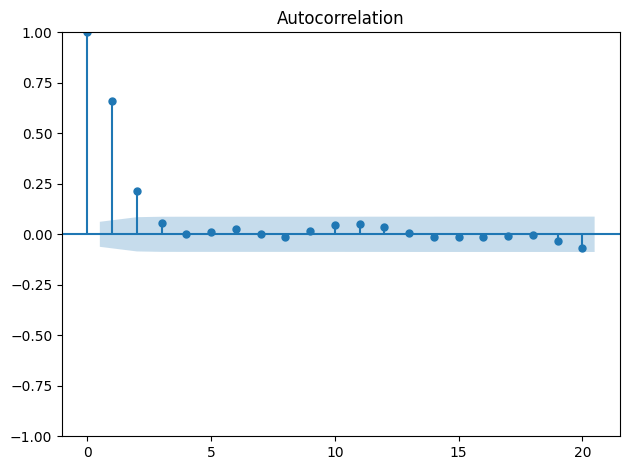

In [5]:
plot_acf(ARMA_1_1, lags=20);

plt.tight_layout()

plt.savefig('figures/adf.png', dpi=300)

### PACF 偏自己相関　をプロット

- 有意な係数と、有意ではない係数の境界が明確ではない正弦波パターン。
- ARMA (1,1)プロセスのpが1であることは推定できない。
- ARMA(1,1)プロセスの次数の特定にPACFプロットを使うことはできない。

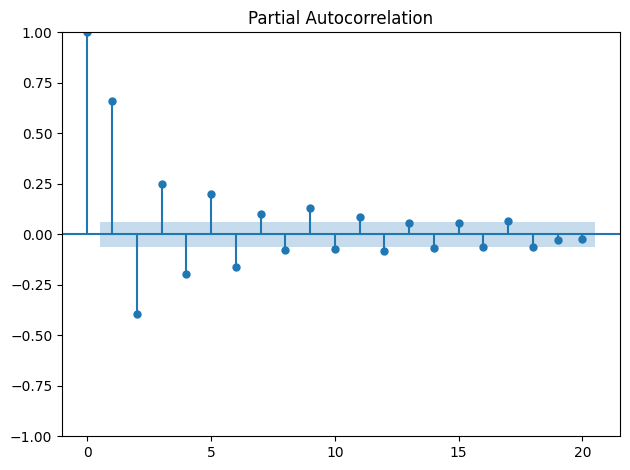

In [6]:
plot_pacf(ARMA_1_1, lags=20);

plt.tight_layout()

plt.savefig('figures/pacf.png', dpi=300)

## ARMA(pq)のモデル化手続

### pとqの値をリストアップ

In [7]:
ps = range(0, 4, 1)
qs = range(0, 4, 1)

order_list = list(product(ps, qs))
print(order_list)

[(0, 0), (0, 1), (0, 2), (0, 3), (1, 0), (1, 1), (1, 2), (1, 3), (2, 0), (2, 1), (2, 2), (2, 3), (3, 0), (3, 1), (3, 2), (3, 3)]


In [8]:
from typing import Union
from tqdm.notebook import tqdm

def optimize_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm(order_list):
        try: 
            model = SARIMAX(endog, order=(order[0], 0, order[1]), simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [9]:
result_df = optimize_ARMA(ARMA_1_1, order_list)
result_df

  0%|          | 0/16 [00:00<?, ?it/s]

,"(p,q)",AIC
0,"(1, 1)",2801.407785
1,"(2, 1)",2802.906070
2,"(1, 2)",2802.967762
3,"(0, 3)",2803.666793
4,"(1, 3)",2804.524027
5,"(3, 1)",2804.588567
6,"(2, 2)",2804.822282
7,"(3, 3)",2806.135228
8,"(2, 3)",2806.175380
9,"(3, 2)",2806.894930
